# Análise do Dataset e Treinamento do Modelo

Notebook de análise exploratoria e treinamento do modelo usando o dataset **UCI HAR - Human Activity Recognition Using Smartphones**.

Fluxo seguido neste notebook:

1. Importar bibliotecas
2. Carregar o dataset
3. Analisar estrutura dos dados
4. Analisar distribuição das classes
5. Visualizar sinais dos sensores
6. Preparar features para treinamento
7. Treinar modelos
8. Comparar resultados
9. Avaliar o modelo escolhido
10. Exportar o modelo compacto para uso embarcado

## 0. Preparação do ambiente

Execute esta célula antes dos imports. Ela instala, no kernel atual do notebook, as bibliotecas necessárias para a análise e o treinamento.

Isso evita o erro `ModuleNotFoundError`, como o erro de `matplotlib` que apareceu no VS Code.

In [4]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

matplotlib_cache = Path.cwd() / '.matplotlib-cache'
matplotlib_cache.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(matplotlib_cache)

packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
}

missing = [pip_name for module_name, pip_name in packages.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print('Instalando depend?ncias ausentes:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('Todas as depend?ncias j? est?o instaladas neste kernel.')


Instalando depend?ncias ausentes: ['numpy', 'pandas', 'scikit-learn', 'matplotlib']


## 1. Imports

Aqui importamos as bibliotecas usadas para carregar dados, analisar, visualizar e treinar modelos.

In [5]:
from pathlib import Path
import os

matplotlib_cache = Path.cwd() / '.matplotlib-cache'
matplotlib_cache.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(matplotlib_cache)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text

%matplotlib inline

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')


## 2. Configurações do projeto

Definimos caminhos, nomes das classes e nomes dos sinais de sensor que vamos usar.

In [6]:
PROJECT_ROOT = Path('..')
DATA_ROOT = PROJECT_ROOT / 'data' / 'uci_har'

ACTIVITY_NAMES = [
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING',
]

SENSOR_FILES = [
    'total_acc_x',
    'total_acc_y',
    'total_acc_z',
    'body_gyro_x',
    'body_gyro_y',
    'body_gyro_z',
]

RANDOM_STATE = 42

## 3. Localizando o dataset

O dataset precisa ter sido baixado antes com:

```bash
python scripts/download_dataset.py
```

In [7]:
def find_dataset_base():
    matches = list(DATA_ROOT.rglob('UCI HAR Dataset'))
    for match in matches:
        if (match / 'train' / 'Inertial Signals').exists() and (match / 'test' / 'Inertial Signals').exists():
            return match
    raise FileNotFoundError('Dataset nao encontrado. Rode: python scripts/download_dataset.py')

dataset_base = find_dataset_base()
dataset_base

WindowsPath('../data/uci_har/UCI HAR Dataset/UCI HAR Dataset')

## 4. Carregando rótulos e sinais inerciais

Vamos carregar os sinais crus de acelerômetro e giroscópio.

Cada arquivo de sinal tem o formato:

- linhas = janelas de movimento
- colunas = 128 leituras dentro daquela janela

In [8]:
def load_signal(split, sensor_name):
    path = dataset_base / split / 'Inertial Signals' / f'{sensor_name}_{split}.txt'
    return np.loadtxt(path)

def load_all_signals(split):
    return {sensor_name: load_signal(split, sensor_name) for sensor_name in SENSOR_FILES}

def load_labels(split):
    path = dataset_base / split / f'y_{split}.txt'
    return np.loadtxt(path, dtype=np.int64) - 1

train_signals = load_all_signals('train')
test_signals = load_all_signals('test')
y_train = load_labels('train')
y_test = load_labels('test')

print('Treino:', len(y_train), 'janelas')
print('Teste:', len(y_test), 'janelas')
print('Formato de um sinal:', train_signals['total_acc_x'].shape)

Treino: 7352 janelas
Teste: 2947 janelas
Formato de um sinal: (7352, 128)


## 5. Análise inicial da estrutura

Nestá etapa conferimos se todos os sinais possuem a mesma quantidade de linhas e colunas.

In [9]:
signal_summary = []

for name, values in train_signals.items():
    signal_summary.append({
        'sinal': name,
        'janelas_treino': values.shape[0],
        'leituras_por_janela': values.shape[1],
        'media_geral': values.mean(),
        'desvio_geral': values.std(),
        'minimo': values.min(),
        'maximo': values.max(),
    })

pd.DataFrame(signal_summary)

,sinal,janelas_treino,leituras_por_janela,media_geral,desvio_geral,minimo,maximo
0,total_acc_x,7352,128,0.804749,0.414112,-0.466556,2.197618
1,total_acc_y,7352,128,0.028755,0.390995,-1.582079,1.217350
2,total_acc_z,7352,128,0.086498,0.357769,-1.639609,1.281363
3,body_gyro_x,7352,128,0.000506,0.406815,-4.733656,4.155473
4,body_gyro_y,7352,128,-0.000824,0.381854,-5.974330,5.746062
5,body_gyro_z,7352,128,0.000113,0.255743,-2.763014,2.365982


## 6. Análise da distribuição das classes

Antes de treinar, verificamos se as classes estáo equilibradas.

Se uma classe tiver muitos exemplos e outra tiver poucos, o modelo pode ficar enviesado.

In [10]:
def class_distribution(labels, split_name):
    counts = np.bincount(labels, minlength=len(ACTIVITY_NAMES))
    return pd.DataFrame({
        'split': split_name,
        'classe': ACTIVITY_NAMES,
        'quantidade': counts,
        'percentual': counts / counts.sum()
    })

dist_train = class_distribution(y_train, 'treino')
dist_test = class_distribution(y_test, 'teste')
dist = pd.concat([dist_train, dist_test], ignore_index=True)
dist

,split,classe,quantidade,percentual
0,treino,WALKING,1226,0.166757
1,treino,WALKING_UPSTAIRS,1073,0.145947
2,treino,WALKING_DOWNSTAIRS,986,0.134113
3,treino,SITTING,1286,0.174918
4,treino,STANDING,1374,0.186888
5,treino,LAYING,1407,0.191376
6,teste,WALKING,496,0.168307
7,teste,WALKING_UPSTAIRS,471,0.159824
8,teste,WALKING_DOWNSTAIRS,420,0.142518
9,teste,SITTING,491,0.166610


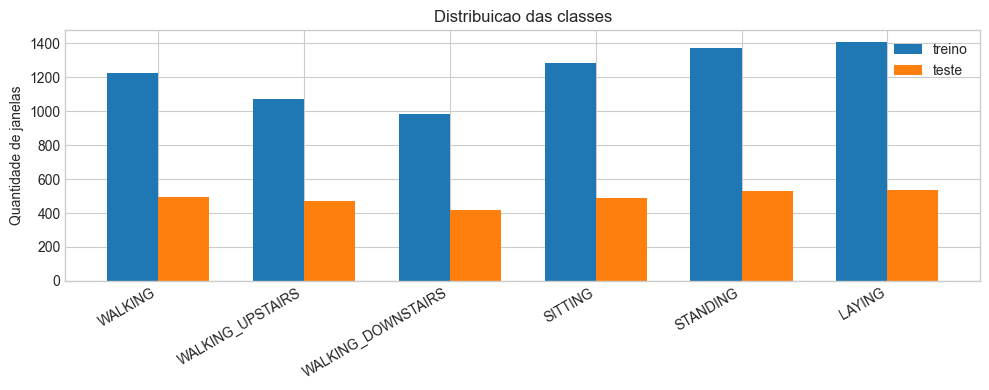

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(ACTIVITY_NAMES))
width = 0.35

ax.bar(x - width / 2, dist_train['quantidade'], width, label='treino')
ax.bar(x + width / 2, dist_test['quantidade'], width, label='teste')
ax.set_xticks(x)
ax.set_xticklabels(ACTIVITY_NAMES, rotation=30, ha='right')
ax.set_ylabel('Quantidade de janelas')
ax.set_title('Distribuicao das classes')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Visualização de sinais do sensor

Agora visualizamos exemplos reais das janelas.

Isso ajuda a perceber que atividades diferentes geram padrões diferentes nos sensores.

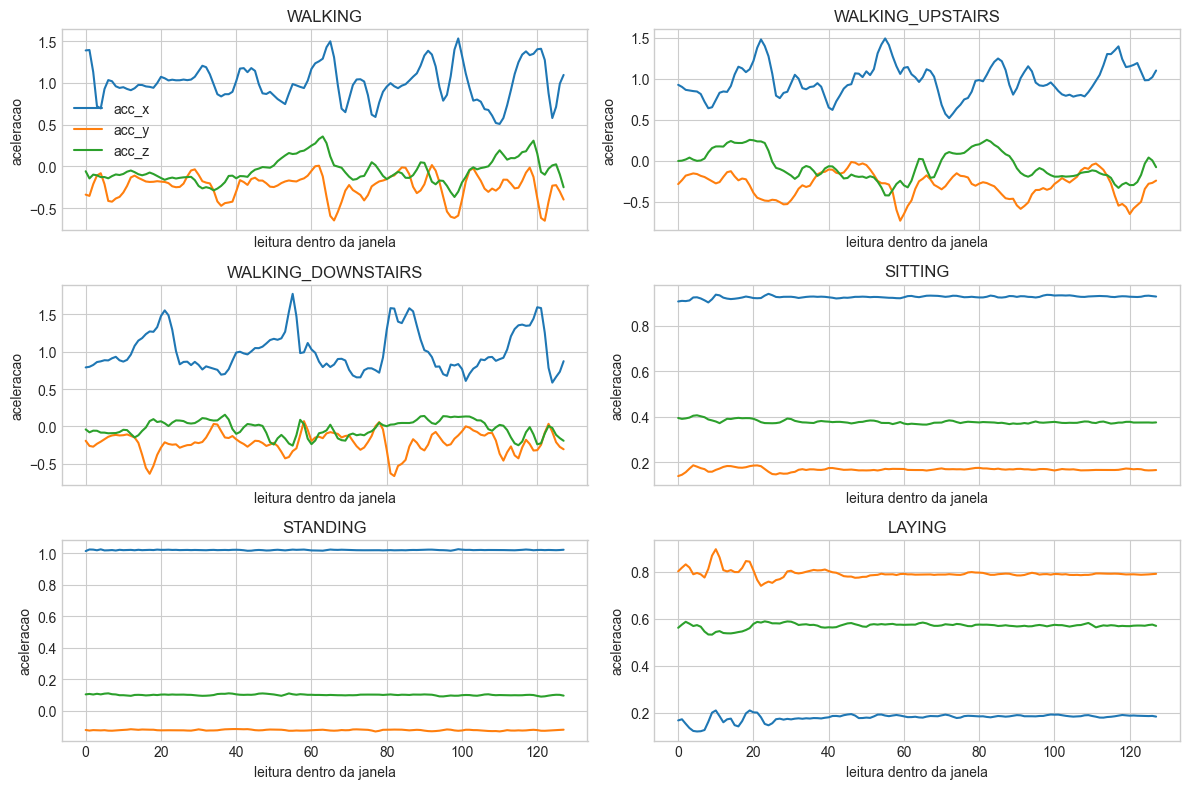

In [12]:
def first_index_of_class(labels, class_index):
    return int(np.where(labels == class_index)[0][0])

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for class_index, ax in enumerate(axes):
    idx = first_index_of_class(y_train, class_index)
    ax.plot(train_signals['total_acc_x'][idx], label='acc_x')
    ax.plot(train_signals['total_acc_y'][idx], label='acc_y')
    ax.plot(train_signals['total_acc_z'][idx], label='acc_z')
    ax.set_title(ACTIVITY_NAMES[class_index])
    ax.set_xlabel('leitura dentro da janela')
    ax.set_ylabel('aceleracao')

axes[0].legend()
plt.tight_layout()
plt.show()

## 8. Feature engineering

Para embarcar em um ESP32-S3, queremos uma entrada pequena.

Por isso, para cada sinal calculamos:

- média
- desvio padrao
- mínimo
- máximo
- RMS

Como são 6 sinais e 5 medidas, ficamos com 30 features por janela.

In [13]:
FEATURE_NAMES = []
for sensor_name in SENSOR_FILES:
    FEATURE_NAMES.extend([
        f'{sensor_name}_mean',
        f'{sensor_name}_std',
        f'{sensor_name}_min',
        f'{sensor_name}_max',
        f'{sensor_name}_rms',
    ])

def extract_features(signals_dict):
    features = []
    for sensor_name in SENSOR_FILES:
        signal = signals_dict[sensor_name]
        features.append(signal.mean(axis=1))
        features.append(signal.std(axis=1))
        features.append(signal.min(axis=1))
        features.append(signal.max(axis=1))
        features.append(np.sqrt((signal * signal).mean(axis=1)))
    return np.column_stack(features)

X_train = extract_features(train_signals)
X_test = extract_features(test_signals)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (7352, 30)
X_test: (2947, 30)


## 9. Tabela final de treino

Aqui criamos um DataFrame para analisar estatísticas das features criadas.

In [14]:
df_train = pd.DataFrame(X_train, columns=FEATURE_NAMES)
df_train['classe'] = [ACTIVITY_NAMES[i] for i in y_train]

df_train.head()

,total_acc_x_mean,total_acc_x_std,total_acc_x_min,total_acc_x_max,total_acc_x_rms,total_acc_y_mean,total_acc_y_std,total_acc_y_min,total_acc_y_max,total_acc_y_rms,...,body_gyro_y_std,body_gyro_y_min,body_gyro_y_max,body_gyro_y_rms,body_gyro_z_mean,body_gyro_z_std,body_gyro_z_min,body_gyro_z_max,body_gyro_z_rms,classe
0,1.019305,0.001791,1.012817,1.024606,1.019306,-0.124262,0.003270,-0.132631,-0.117210,0.124305,...,0.019828,-0.009022,0.074850,0.027742,0.009468,0.005943,-0.006891,0.022859,0.011179,STANDING
1,1.019448,0.001932,1.012893,1.024606,1.019450,-0.122936,0.004930,-0.132631,-0.108560,0.123034,...,0.010356,-0.030160,0.016858,0.011219,0.006308,0.007431,-0.009759,0.025133,0.009747,STANDING
2,1.019927,0.002904,1.009013,1.027664,1.019931,-0.124997,0.006460,-0.137142,-0.108560,0.125164,...,0.006920,-0.037503,0.000761,0.014410,0.004335,0.008753,-0.009759,0.028609,0.009768,STANDING
3,1.020349,0.002574,1.009013,1.027664,1.020352,-0.130493,0.004029,-0.143545,-0.116749,0.130555,...,0.007793,-0.037503,0.007778,0.010953,-0.000352,0.008186,-0.013223,0.028609,0.008194,STANDING
4,1.020255,0.001949,1.013645,1.026194,1.020257,-0.130209,0.003876,-0.143545,-0.121456,0.130267,...,0.007815,-0.020582,0.017447,0.007817,-0.003957,0.008260,-0.021141,0.019890,0.009159,STANDING


In [15]:
df_train.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
total_acc_x_mean,7352.0,0.804749,0.366131,-0.370700,0.902589,0.983997,1.011098,1.055335
total_acc_x_std,7352.0,0.127444,0.145657,0.001340,0.003414,0.013844,0.245544,0.648704
total_acc_x_min,7352.0,0.585812,0.350926,-0.466556,0.355264,0.583927,0.961749,1.022497
total_acc_x_max,7352.0,1.124611,0.608197,-0.314170,0.960782,1.035682,1.607995,2.197618
total_acc_x_rms,7352.0,0.834951,0.349262,0.002962,0.918277,1.004153,1.025339,1.148428
total_acc_y_mean,7352.0,0.028755,0.372431,-0.494512,-0.220897,-0.124932,0.167153,1.005326
total_acc_y_std,7352.0,0.082753,0.085700,0.001510,0.004724,0.019710,0.164297,0.369380
total_acc_y_min,7352.0,-0.215919,0.562020,-1.582079,-0.679154,-0.257903,0.124988,0.993726
total_acc_y_max,7352.0,0.196441,0.319585,-0.444567,-0.012442,0.120476,0.335699,1.217350
total_acc_y_rms,7352.0,0.319868,0.226706,0.003017,0.174738,0.263969,0.385737,1.005337


## 10. Comparando classes por uma feature

Um passo comum em EDA e verificar se algumas features mudam conforme a classe.

Abaixo olhamos o desvio padrao da aceleracao no eixo X por atividade.

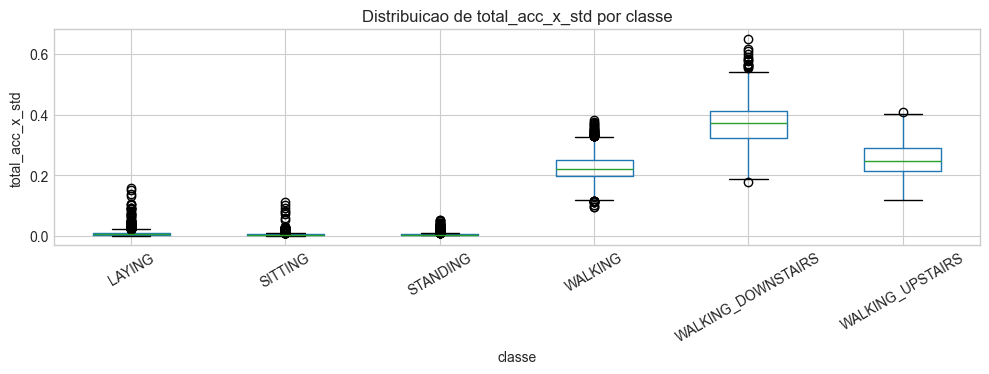

In [16]:
feature_to_plot = 'total_acc_x_std'

fig, ax = plt.subplots(figsize=(10, 4))
df_train.boxplot(column=feature_to_plot, by='classe', ax=ax, rot=30)
ax.set_title(f'Distribuicao de {feature_to_plot} por classe')
ax.set_ylabel(feature_to_plot)
plt.suptitle('')
plt.tight_layout()
plt.show()

## 11. Baseline

Antes de treinar o modelo real, criamos um baseline.

O baseline e um modelo bobo que sempre tenta chutar a classe mais frequente.

O nosso modelo real precisa ser melhor que isso.

In [17]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_acc

0.18221920597217509

## 12. Treinamento de modelos

Treinamos duas árvores:

1. árvore completa: usada como comparação.
2. árvore compacta: modelo escolhido para embarcar.

A árvore compacta tem limite de profundidade para ficar menor.

In [18]:
modelo_completo = DecisionTreeClassifier(random_state=RANDOM_STATE)
modelo_compacto = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)

modelo_completo.fit(X_train, y_train)
modelo_compacto.fit(X_train, y_train)

print('Nos da arvore completa:', modelo_completo.tree_.node_count)
print('Nos da arvore compacta:', modelo_compacto.tree_.node_count)

Nos da arvore completa: 593
Nos da arvore compacta: 61


## 13. Validação cruzada no treino

A validação cruzada mede o desempenho do modelo em diferentes partes do conjunto de treino.

Isso ajuda a verificar se o resultado não depende de uma única divisão dos dados.

In [19]:
cv_scores = cross_val_score(modelo_compacto, X_train, y_train, cv=5, scoring='accuracy')

print('Acuracias da validacao cruzada:', np.round(cv_scores, 4))
print('Media:', cv_scores.mean())
print('Desvio:', cv_scores.std())

Acuracias da validacao cruzada: [0.8212 0.7845 0.815  0.7361 0.8327]
Media: 0.7978767740950902
Desvio: 0.034775870510045506


## 14. Avaliação no conjunto de teste

Agora avaliamos com dados que o modelo não usou no treinamento.

In [20]:
pred_completo = modelo_completo.predict(X_test)
pred_compacto = modelo_compacto.predict(X_test)

results = pd.DataFrame([
    {
        'modelo': 'baseline',
        'acuracia_teste': baseline_acc,
        'nos_arvore': 0,
    },
    {
        'modelo': 'arvore_completa',
        'acuracia_teste': accuracy_score(y_test, pred_completo),
        'nos_arvore': modelo_completo.tree_.node_count,
    },
    {
        'modelo': 'arvore_compacta',
        'acuracia_teste': accuracy_score(y_test, pred_compacto),
        'nos_arvore': modelo_compacto.tree_.node_count,
    },
])

results

,modelo,acuracia_teste,nos_arvore
0,baseline,0.182219,0
1,arvore_completa,0.759756,593
2,arvore_compacta,0.784187,61


## 15. Relatório de classificação

O relatorio mostra precision, recall e f1-score para cada classe.

In [21]:
print(classification_report(y_test, pred_compacto, target_names=ACTIVITY_NAMES))

                    precision    recall  f1-score   support

           WALKING       0.73      0.62      0.67       496
  WALKING_UPSTAIRS       0.56      0.80      0.66       471
WALKING_DOWNSTAIRS       0.83      0.57      0.68       420
           SITTING       0.89      0.73      0.80       491
          STANDING       0.79      0.92      0.85       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.78      2947
         macro avg       0.80      0.77      0.78      2947
      weighted avg       0.80      0.78      0.78      2947



## 16. Matriz de confusão

A matriz de confusão mostra em quais classes o modelo acerta e em quais ele confunde.

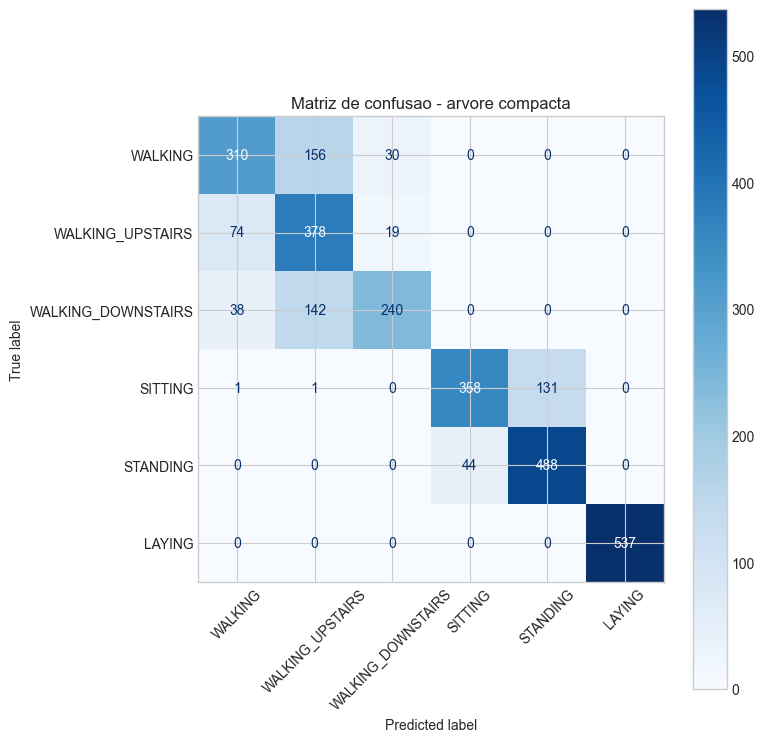

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_compacto,
    display_labels=ACTIVITY_NAMES,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax,
)
ax.set_title('Matriz de confusao - arvore compacta')
plt.tight_layout()
plt.show()

## 17. Importância das features

Aqui vemos quais características foram mais importantes para a árvore tomar decisões.

In [23]:
feature_importance = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': modelo_compacto.feature_importances_,
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
0,total_acc_x_mean,0.290859
1,total_acc_x_std,0.254573
5,total_acc_y_mean,0.224931
3,total_acc_x_max,0.127986
15,body_gyro_x_mean,0.050396
18,body_gyro_x_max,0.013751
9,total_acc_y_rms,0.008810
17,body_gyro_x_min,0.008144
19,body_gyro_x_rms,0.008034
8,total_acc_y_max,0.004149


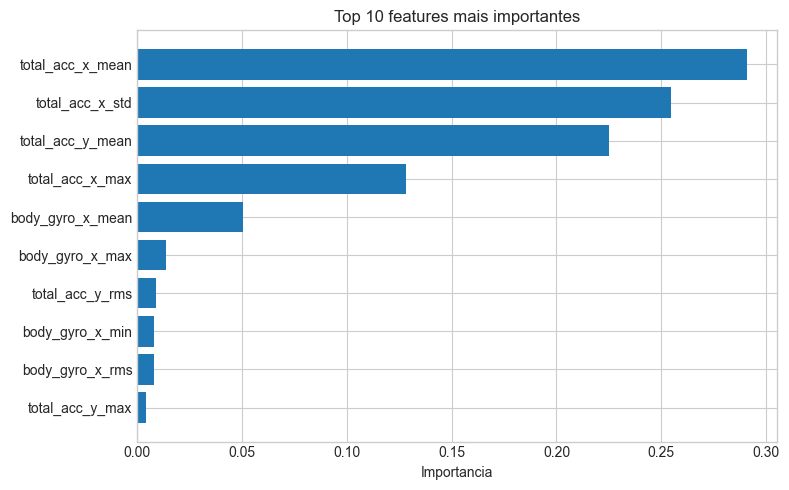

In [24]:
top_features = feature_importance.head(10).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_features['feature'], top_features['importance'])
ax.set_title('Top 10 features mais importantes')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 18. Regras aprendidas pela árvore

Como a árvore de decisão e interpretável, conseguimos imprimir parte das regras aprendidas.

In [25]:
tree_rules = export_text(modelo_compacto, feature_names=FEATURE_NAMES, max_depth=3)
print(tree_rules)

|--- total_acc_x_mean <= 0.39
|   |--- class: 5
|--- total_acc_x_mean >  0.39
|   |--- total_acc_x_std <= 0.09
|   |   |--- total_acc_y_mean <= -0.07
|   |   |   |--- body_gyro_x_min <= -0.01
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- body_gyro_x_min >  -0.01
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- total_acc_y_mean >  -0.07
|   |   |   |--- total_acc_x_mean <= 1.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- total_acc_x_mean >  1.00
|   |   |   |   |--- truncated branch of depth 3
|   |--- total_acc_x_std >  0.09
|   |   |--- total_acc_x_max <= 1.83
|   |   |   |--- total_acc_y_mean <= -0.28
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- total_acc_y_mean >  -0.28
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- total_acc_x_max >  1.83
|   |   |   |--- total_acc_x_std <= 0.33
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- total_acc_x_std >  0.33
|   |   |   |   |--- trun

## 19. Testando uma amostra individual

Aqui pegamos uma janela do conjunto de teste e verificamos a predição do modelo.

In [26]:
sample_index = 0
sample_features = X_test[sample_index]
real_class = y_test[sample_index]
predicted_class = modelo_compacto.predict([sample_features])[0]
probabilities = modelo_compacto.predict_proba([sample_features])[0]

print('Classe real:', ACTIVITY_NAMES[real_class])
print('Classe prevista:', ACTIVITY_NAMES[predicted_class])
print('\nProbabilidades por classe:')
pd.DataFrame({
    'classe': ACTIVITY_NAMES,
    'probabilidade': probabilities,
}).sort_values('probabilidade', ascending=False)

Classe real: STANDING
Classe prevista: STANDING

Probabilidades por classe:


,classe,probabilidade
4,STANDING,0.998571
3,SITTING,0.001429
1,WALKING_UPSTAIRS,0.000000
0,WALKING,0.000000
2,WALKING_DOWNSTAIRS,0.000000
5,LAYING,0.000000


## 20. Exportação do modelo para embarcado

O treino oficial do projeto e feito pelo script:

```bash
python scripts/train_and_export.py
```

Esse script repete a preparação das features, treina a árvore compacta e exporta o modelo para C/C++.

O arquivo exportado fica em:

```text
firmware/wokwi/model_data.h
```

No Wokwi, o ESP32-S3 usa esse arquivo para fazer a inferencia.

In [27]:
model_header = PROJECT_ROOT / 'firmware' / 'wokwi' / 'model_data.h'
print('Arquivo exportado existe?', model_header.exists())
print('Caminho:', model_header)

if model_header.exists():
    for line in model_header.read_text(encoding='utf-8').splitlines()[:20]:
        print(line)

Arquivo exportado existe? True
Caminho: ..\firmware\wokwi\model_data.h
#pragma once

// Arquivo gerado por scripts/train_and_export.py.
// Ele contem a arvore de decisao treinada e pronta para embarcar.

const int FEATURE_COUNT = 30;
const int CLASS_COUNT = 6;
const int NODE_COUNT = 61;

const char* CLASS_NAMES[CLASS_COUNT] = {
  "WALKING",
  "WALKING_UPSTAIRS",
  "WALKING_DOWNSTAIRS",
  "SITTING",
  "STANDING",
  "LAYING",
};

const char* FEATURE_NAMES[FEATURE_COUNT] = {
  "total_acc_x_mean",


## 21. Conclusão da análise

Conclusões principais:

- O dataset possui sinais de acelerômetro e giroscópio separados em janelas.
- Cada janela foi resumida em 30 features estatísticas.
- A árvore compacta teve desempenho melhor que o baseline.
- A limitacao da profundidade reduziu o tamanho do modelo.
- O modelo final foi exportado para C/C++ para rodar no ESP32-S3 simulado no Wokwi.